<a href="https://colab.research.google.com/github/KarthiApi/WesternUnion/blob/main/DA_FINAL_PROJECT_TEMPLATE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title

Cross-Border Transaction Risk Modeling & AML Behavioral Analytics Project

# **Objective(Problem statment)**


1. To clean and analyze global transaction data to find suspicious patterns, create clear charts, and give recommendations to improve AML compliance.

2. To use data cleaning and analysis to spot financial risk trends and build simple dashboards that help optimize Western Union’s compliance screening.

3. To turn raw transaction logs into clean data and visual reports, making it easy to identify fraud patterns and reduce false compliance alerts.

4. To provide actionable insights and recommendations from the analysis

# Outcome

The project successfully uncovered key patterns, trends, and hidden insights from the Western Union dataset. This analysis provided a clear understanding of cross-border transaction behaviors and supported the compliance team's decision-making with evidence-based findings to improve risk detection.

# Domain
FinTech / Global Cross-Border Banking (Compliance & AML Analytics)

#**Dataset Information**

#**Dataset Information**

**Source:** https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml

**Year / Timeline:** Data collected during 2020 to 2025

**Dataset Column/features Description:**

Transaction ID - The unique alphanumeric code generated by the system for each record.

MTCN (Money Transfer Control Number) - The unique 10-digit tracking number assigned by Western Union to every money transfer.

Sender Name - The full name of the customer who is sending the money.

Receiver Name - The full name of the beneficiary who is receiving the money.

PEP Related - Indicates whether the sender or receiver is a Politically Exposed Person, which requires enhanced compliance screening.

Sender Currency - The ISO currency code used by the sender at the origin country (e.g., USD, CAD, GBP).

Receiver Currency - The ISO currency code received by the beneficiary at the destination country (e.g., EUR, INR, BRL).

KYC Status - The identity verification stage of the customer (such as Verified, Unverified, Pending, or Non-KYC).

Transaction Type - Classifies how the funds move through the network (Internal, External, Inter-transaction, or Outer-transaction).

Amount - The total monetary value of the transaction, used to detect structuring or suspicious transfer limits.

Channel - The platform used to process the money transfer (e.g., Web Portal, Mobile App, ATM, Agent Network, Branch Counter).

Risk Rating - The system-generated risk level assigned to the transaction (Low, Medium, High, Critical) for investigator review.

Timestamp - The exact date and time the transaction took place, spanning from 2020 to 2026.

Sender Age - The demographic age of the customer initiating the money transfer.

Sender Country - The country where the money transfer originated.

Receiver Country - The destination country where the money is being received.

Customer Address - The physical address associated with the account holder for compliance validation.

# Stages for DA Project

## Stage 1 – Problem Definition and Dataset Selection


**NOTE : THINGS TO BE COMPLETED**

* Define the business problem and expected outcome

* Choose dataset and explain its source, size, and features

* Import libraries, load dataset

* Dataset description (rows, columns, features)

* Initial EDA (head, info, describe, shape, null checks, duplicate check)

In [1]:
import pandas as pd
import numpy as np

# Load dataset
file_path = "/content/updated_westernunion_compliance_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")


Dataset loaded successfully.


In [2]:
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Dimensions: 1165 rows, 17 columns


In [3]:
df.head(3)

,Transaction ID,MTCN,Sender Name,Receiver Name,PEP Related,Sender Currency,Receiver Currency,KYC Status,Transaction Type,Amount,Channel,Risk Rating,Timestamp,Sender Age,Sender Country,Receiver Country,Customer Address
0,TXN1000001,95822412.0,Patricia Smith,fatima rodriguez,No,GBP,BRL,KYC,Outer-transaction,3497.59,Agent Network,Low,2020-07-25 22:28,69,France,Brazil,"5241 Cedar Ln, Dubai"
1,TXN1000002,31429110.0,Elena Wilson,Richard Rodriguez,No,CAD,EUR,NaN,outer-transaction,8048.06,ATM,Low,2026-01-07 16:31,32,Germany,South Africa,"2808 Main St, Toronto"
2,TXN1000003,20709497.0,Zayn Davis,Zayn Brown,No,SGD,ZAR,NaN,EXTERNAL,1080.32,Web Portal,Medium,2020-06-13 06:29,78,Germany,Brazil,"3373 Pine Rd, London"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1165 entries, 0 to 1164
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Transaction ID     1165 non-null   object 
 1   MTCN               1112 non-null   float64
 2   Sender Name        1136 non-null   object 
 3   Receiver Name      1133 non-null   object 
 4   PEP Related        1165 non-null   object 
 5   Sender Currency    1143 non-null   object 
 6   Receiver Currency  1143 non-null   object 
 7   KYC Status         929 non-null    object 
 8   Transaction Type   1165 non-null   object 
 9   Amount             1165 non-null   float64
 10  Channel            1165 non-null   object 
 11  Risk Rating        1165 non-null   object 
 12  Timestamp          1165 non-null   object 
 13  Sender Age         1165 non-null   int64  
 14  Sender Country     1165 non-null   object 
 15  Receiver Country   1165 non-null   object 
 16  Customer Address   1165 

In [5]:
df.isnull().sum()

,0
Transaction ID,0
MTCN,53
Sender Name,29
Receiver Name,32
PEP Related,0
Sender Currency,22
Receiver Currency,22
KYC Status,236
Transaction Type,0
Amount,0


In [6]:
print(f"Total Completely Duplicated Rows: {df.duplicated().sum()}")

Total Completely Duplicated Rows: 0


In [7]:
df.describe(include='all')

,Transaction ID,MTCN,Sender Name,Receiver Name,PEP Related,Sender Currency,Receiver Currency,KYC Status,Transaction Type,Amount,Channel,Risk Rating,Timestamp,Sender Age,Sender Country,Receiver Country,Customer Address
count,1165,1.112000e+03,1136,1133,1165,1143,1143,929,1165,1165.000000,1165,1165,1165,1165.000000,1165,1165,1165
unique,1150,NaN,693,681,8,25,24,5,6,NaN,5,4,1165,NaN,10,10,1163
top,TXN1001132,NaN,Fatima Brown,Patricia Smith,No,AED,AUD,Pending,inter-transaction,NaN,Web Portal,Low,2023-11-23 12:07,NaN,UK,South Africa,"4775 Pine Rd, London"
freq,2,NaN,6,7,782,104,105,217,218,NaN,249,305,1,NaN,126,127,2
mean,NaN,5.481050e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7487.341768,NaN,NaN,NaN,51.068670,NaN,NaN,NaN
std,NaN,2.610604e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4375.370603,NaN,NaN,NaN,19.796614,NaN,NaN,NaN
min,NaN,1.000127e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.500000,NaN,NaN,NaN,18.000000,NaN,NaN,NaN
25%,NaN,3.269843e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3528.440000,NaN,NaN,NaN,34.000000,NaN,NaN,NaN
50%,NaN,5.360523e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7517.900000,NaN,NaN,NaN,51.000000,NaN,NaN,NaN
75%,NaN,7.650407e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11331.430000,NaN,NaN,NaN,69.000000,NaN,NaN,NaN


## Stage 2 – Data Cleaning and Pre-processing

- Handle missing values (impute or drop)

- Handle duplicates
- column name rename or dropping unwanted columns if required

- Treat outliers if required

- Check skewness and apply transformations

- Convert data types if needed

- Feature transformations (date parts, derived fields if required for analysis)

In [ ]:
# your code here
# If you want more cells, you can add or less cells you can remove, but dont change the structure.

In [ ]:
# your code here
# If you want more cells, you can add or less cells you can remove, but dont change the structure.

In [ ]:
# your code here
# If you want more cells, you can add or less cells you can remove, but dont change the structure.

In [ ]:
# your code here
# If you want more cells, you can add or less cells you can remove, but dont change the structure.

In [ ]:
# your code here
# If you want more cells, you can add or less cells you can remove, but dont change the structure.

## Stage 3 – EDA and Visualizations

Univariate Analysis → distribution of single variables (countplot, histogram, boxplot)

Bivariate Analysis → relation between two variables (scatterplot, barplot, correlation heatmap)

Multivariate Analysis → relation among 3+ variables (pairplot, grouped analysis, pivot tables, advanced plots)

Interpretation MUST with every visualization

Focus on business story not just charts

Each chart must be in seperate cells.

# **Note For Kind of Analysis to be done**

**Type of Analysis**

* Descriptive Analysis (summarizing the dataset)

* Diagnostic Analysis (finding reasons behind patterns)

* Predictive Analysis (optional if forecasting required using basic stats)

* Prescriptive Analysis (recommendations for business decisions)

### Analysis about the sales by region

In [ ]:
# your chart here
# If you want more cells, you can add or less cells you can remove, but dont change the structure.

### **Insights**

* point by point insight should be recorded

## Interpretation of your above chart

Explain the Chart.

What is it saying?

What features you used?

From this what you are showing us?

In [ ]:
# your code here
# If you want more cells, you can add or less cells you can remove, but dont change the structure.

## Interpretation of your above chart

Explain the Chart.

What is it saying?

What features you used?

From this what you are showing us?

In [ ]:
# your code here
# If you want more cells, you can add or less cells you can remove, but dont change the structure.

## Interpretation of your above chart

Explain the Chart.

What is it saying?

What features you used?

From this what you are showing us?

In [ ]:
# your code here
# If you want more cells, you can add or less cells you can remove, but dont change the structure.

## Interpretation of your above chart

Explain the Chart.

What is it saying?

What features you used?

From this what you are showing us?

In [ ]:
# your code here
# If you want more cells, you can add or less cells you can remove, but dont change the structure.

## Interpretation of your above chart

Explain the Chart.

What is it saying?

What features/columns you used?

From this what you are showing us?

## **Steps to Download your cleaned data for dashboard creation using Power BI**


In [ ]:
import pandas as pd
df=pd.read_csv("https://raw.githubusercontent.com/geethag-sys/Health-care-analysis3/refs/heads/main/insurance.csv")
df.to_csv("insurance.csv")

## Stage 4 – Documentation, Insights and Presentation

Show a dashboard aligning all the charts in powerbi by connecting python in PowerBI

Summarize findings in plain English (what do the patterns mean)

Highlight 3–5 key insights (trends, anomalies, correlations)

Provide recommendations for business or decision-making

Explain the FINAL STORY WITH THE DASHBOARD/report

Create a PDF pasting your DASHBOARD, explaining all the above mentioned concepts and submit it


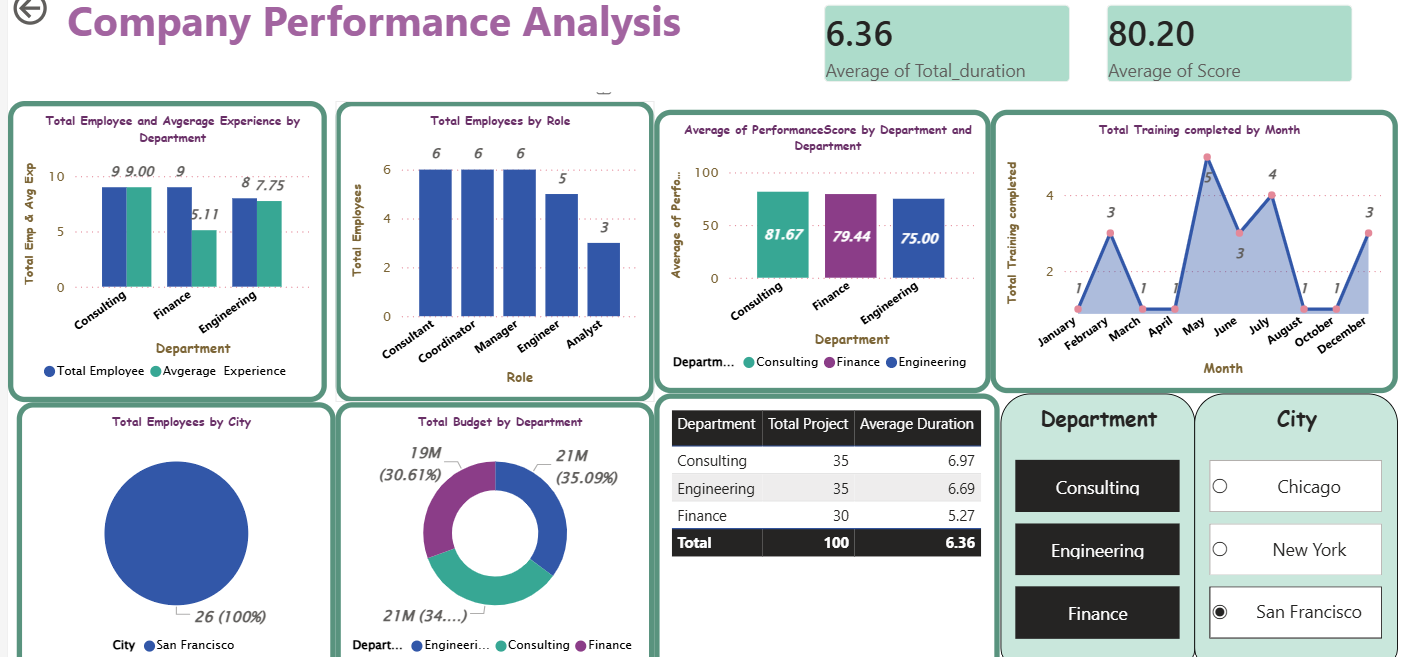

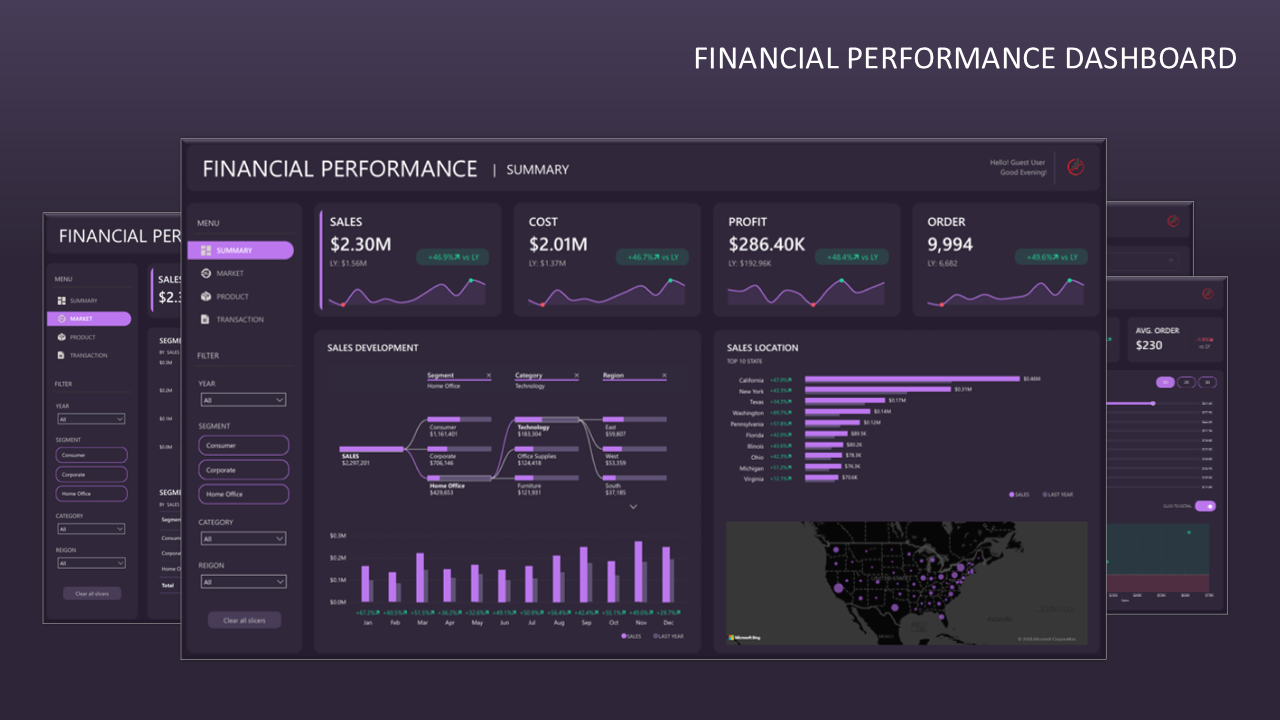

In [ ]:
# your stage 4 pdf Link

'''
step1 --> Create a docs that should have all the above mentioned
step2 --> Save it as "Stage4_doc"
Step3 --> Download it as PDF
step4 --> Upload the pdf in your drive
step5 --> Right click on your pdf in drive
step6 --> click share and change access into anyone with the link (Viewer)
step7 --> click copy link and paste it here...
You are done.
'''

## **Final Overall Insights:**
* insights from the final dashboard observation on the basics of 4 types of analysis

# Future Enhancement

Use a larger or more recent dataset for deeper insights

Automate parts of the analysis with scripts or dashboards

Add advanced visualizations and interactive dashboards in Power BI or Tableau

Extend the analysis to predictive modeling for forecasting if needed

# Conclusion

From the analysis, we identified meaningful relationships and patterns in the dataset. The visualizations and insights highlight the main factors influencing the outcomes and provide a strong foundation for business decisions.